In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset , DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using Device: {device}")

using Device: cuda


In [4]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file == "fashion-mnist_train.csv":
            print(os.path.join(root, file))

/content/drive/MyDrive/Colab Notebooks/fashion-mnist_train.csv


In [8]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/fashion-mnist_train.csv")

In [9]:
test_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/fashion-mnist_test.csv")

In [10]:
df.shape

(60000, 785)

In [11]:
test_df.shape

(10000, 785)

In [12]:
X = df.iloc[: , 1:].values
y = df.iloc[: , 0].values

In [13]:
# First split: 80% train, 20% test
# X_train, X_test, y_train, y_test = train_test_split(
#     X,
#     y,
#     test_size=0.2,
#     random_state=42,
#     stratify=y
# )

X_train = X
y_train = y
X_test = test_df.iloc[: , 1:].values
y_test = test_df.iloc[: , 0].values

# Second split: take 20% of training data for validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (48000, 784)
Validation: (12000, 784)
Test: (10000, 784)


In [14]:
X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

In [15]:
class CustomDataset(Dataset):

    def __init__(self, features, labels):

        self.features = torch.tensor(
            features,
            dtype=torch.float32
        )

        self.labels = torch.tensor(
            labels,
            dtype=torch.long
        )

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):

        return self.features[index], self.labels[index]

In [16]:
train_dataset = CustomDataset(X_train, y_train)
val_dataset = CustomDataset(X_val, y_val)
test_dataset = CustomDataset(X_test, y_test)

In [17]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    pin_memory=True
)

Training without Hyperparameter tuning

In [ ]:
# print("Train dataset:", len(train_dataset))
#  print("Train loader:", len(train_loader))

In [ ]:
# class MyNN(nn.Module):
#   def __init__(self, num_features):
#     super(MyNN, self).__init__()
#     self.model = nn.Sequential(
#         nn.Linear(num_features, 128),
#         # Adding BatchNorm function to reduce overfitting
#         nn.BatchNorm1d(128),
#         nn.ReLU(),
#         # Adding dropout function to reduce overfitting
#         nn.Dropout(p = 0.3),
#         nn.Linear(128, 64),
#         nn.BatchNorm1d(64) ,
#         nn.ReLU(),
#         nn.Dropout(p = 0.3),
#         nn.Linear(64, 10)
#     )

#   def forward(self, x):
#       return self.model(x)

In [ ]:
# learning_rate = 0.1
# epochs = 100

In [ ]:
# model = MyNN(X_train.shape[1])
# model.to(device)

# criterion = nn.CrossEntropyLoss()
# optimizer = optim.SGD(model.parameters(), lr=learning_rate , weight_decay= 1e-4)
# # ADDing regularization term thorugh weight_decay and lamda is 1e-4

In [ ]:
# for epoch in range(epochs):
#   total_epoch_loss =0

#   for batch_features, batch_labels in train_loader:
#     batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

#     outputs = model(batch_features)

#     loss = criterion(outputs, batch_labels)

#     optimizer.zero_grad()

#     loss.backward()

#     optimizer.step()

#     total_epoch_loss += loss.item()

#   print(f"Epoch: {epoch+1}, Loss: {total_epoch_loss/len(train_loader)}")


In [ ]:
# total = 0
# correct = 0
# with torch.no_grad():
#   for batch_features, batch_labels in test_loader:
#     batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
#     outputs = model(batch_features)
#     _, predicted = torch.max(outputs.data, 1)
#     total += batch_labels.size(0)
#     correct += (predicted == batch_labels).sum().item()
# print(correct / total)

In [ ]:
# total = 0
# correct = 0
# with torch.no_grad():
#   for batch_features, batch_labels in train_loader:
#     batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
#     outputs = model(batch_features)
#     _, predicted = torch.max(outputs.data, 1)
#     total += batch_labels.size(0)
#     correct += (predicted == batch_labels).sum().item()
# print(correct / total)

Hyperparameter tuning using optuna

In [18]:
class MyNN(nn.Module):

  def __init__(self, input_dim, output_dim, num_hidden_layers, neurons_per_layer, dropout_rate):

    super().__init__()

    layers = []

    for i in range(num_hidden_layers):

      layers.append(nn.Linear(input_dim, neurons_per_layer))
      layers.append(nn.BatchNorm1d(neurons_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(dropout_rate))
      input_dim = neurons_per_layer

    layers.append(nn.Linear(neurons_per_layer, output_dim))

    self.model = nn.Sequential(*layers)

  def forward(self, x):

    return self.model(x)

In [19]:
def objective(trial):

    # Hyperparameters
    num_hidden_layers = trial.suggest_int("num_hidden_layers", 1, 5)
    neurons_per_layer = trial.suggest_int("neurons_per_layer", 8, 128, step=8)
    epochs = trial.suggest_int("epochs", 10, 50, step=10)
    learning_rate = trial.suggest_float("learning_rate",1e-5,1e-1,log=True)
    dropout_rate = trial.suggest_float("dropout_rate",0.1,0.5,step=0.1)
    batch_size = trial.suggest_categorical("batch_size",[16, 32, 64, 128])
    optimizer_name = trial.suggest_categorical("optimizer",["Adam", "SGD", "RMSprop"])
    weight_decay = trial.suggest_float("weight_decay",1e-5,1e-3,log=True)


    # DataLoaders for this trial
    train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True,pin_memory=True)

    val_loader = DataLoader(val_dataset,batch_size=batch_size,shuffle=False,pin_memory=True)


    # Model
    model = MyNN(
        input_dim=784,
        output_dim=10,
        num_hidden_layers=num_hidden_layers,
        neurons_per_layer=neurons_per_layer,
        dropout_rate=dropout_rate
    ).to(device)


    # Loss
    criterion = nn.CrossEntropyLoss()


    # Optimizer
    if optimizer_name == "Adam":

        optimizer = optim.Adam(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

    elif optimizer_name == "SGD":

        optimizer = optim.SGD(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

    else:

        optimizer = optim.RMSprop(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )


    # Training
    for epoch in range(epochs):

        model.train()

        for batch_features, batch_labels in train_loader:

            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)

            outputs = model(batch_features)

            loss = criterion(outputs, batch_labels)

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()


    # Validation
    model.eval()

    total = 0
    correct = 0

    with torch.no_grad():

        for batch_features, batch_labels in val_loader:

            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)

            outputs = model(batch_features)

            _, predicted = torch.max(outputs, 1)

            total += batch_labels.size(0)

            correct += (predicted == batch_labels).sum().item()


    validation_accuracy = correct / total

    return validation_accuracy

In [20]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 30.3 MB/s eta 0:00:00


In [21]:
import optuna

study = optuna.create_study(direction="maximize")
study.optimize(
    objective,
    n_trials=20
)

[I 2026-09-09 17:33:26,070] A new study created in memory with name: no-name-c0a815e2-ad43-4d69-96e0-2e118567935f
[I 2026-09-09 17:33:51,871] Trial 0 finished with value: 0.5910833333333333 and parameters: {'num_hidden_layers': 1, 'neurons_per_layer': 16, 'epochs': 10, 'learning_rate': 6.85929237885376e-05, 'dropout_rate': 0.30000000000000004, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 8.738150574591079e-05}. Best is trial 0 with value: 0.5910833333333333.
[I 2026-09-09 17:35:13,425] Trial 1 finished with value: 0.8834166666666666 and parameters: {'num_hidden_layers': 4, 'neurons_per_layer': 80, 'epochs': 30, 'learning_rate': 0.00015025844450358152, 'dropout_rate': 0.30000000000000004, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.0008272989560348472}. Best is trial 1 with value: 0.8834166666666666.
[I 2026-09-09 17:36:03,195] Trial 2 finished with value: 0.8505833333333334 and parameters: {'num_hidden_layers': 1, 'neurons_per_layer': 32, 'epochs': 50, 'learnin

In [22]:
print("Best validation accuracy:", study.best_value)
print("Best parameters:")
print(study.best_params)

Best validation accuracy: 0.8931666666666667
Best parameters:
{'num_hidden_layers': 3, 'neurons_per_layer': 128, 'epochs': 40, 'learning_rate': 0.0004106636441800266, 'dropout_rate': 0.30000000000000004, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.00016197353795233948}


In [23]:
best_params = study.best_params
final_train_loader = DataLoader(
    train_dataset,
    batch_size=best_params["batch_size"],
    shuffle=True,
    pin_memory=True
)

In [24]:
final_model = MyNN(
    input_dim=784,
    output_dim=10,
    num_hidden_layers=best_params["num_hidden_layers"],
    neurons_per_layer=best_params["neurons_per_layer"],
    dropout_rate=best_params["dropout_rate"]
).to(device)

In [25]:
if best_params["optimizer"] == "Adam":

    final_optimizer = optim.Adam(
        final_model.parameters(),
        lr=best_params["learning_rate"],
        weight_decay=best_params["weight_decay"]
    )

elif best_params["optimizer"] == "SGD":

    final_optimizer = optim.SGD(
        final_model.parameters(),
        lr=best_params["learning_rate"],
        weight_decay=best_params["weight_decay"]
    )

else:

    final_optimizer = optim.RMSprop(
        final_model.parameters(),
        lr=best_params["learning_rate"],
        weight_decay=best_params["weight_decay"]
    )

In [26]:
def calculate_accuracy(model, loader):

    model.eval()

    total = 0
    correct = 0

    with torch.no_grad():

        for batch_features, batch_labels in loader:

            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)

            outputs = model(batch_features)

            _, predicted = torch.max(outputs, 1)

            total += batch_labels.size(0)

            correct += (predicted == batch_labels).sum().item()

    return correct / total

In [28]:
criterion = nn.CrossEntropyLoss()

best_val_accuracy = 0
patience = 5
patience_counter = 0

for epoch in range(best_params["epochs"]):

    final_model.train()

    total_loss = 0

    for batch_features, batch_labels in final_train_loader:

        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        outputs = final_model(batch_features)

        loss = criterion(outputs, batch_labels)

        final_optimizer.zero_grad()

        loss.backward()

        final_optimizer.step()

        total_loss += loss.item()


    avg_loss = total_loss / len(final_train_loader)

    val_accuracy = calculate_accuracy(
        final_model,
        val_loader
    )


    print(
        f"Epoch {epoch + 1}/{best_params['epochs']} "
        f"- Loss: {avg_loss:.4f} "
        f"- Val Accuracy: {val_accuracy * 100:.2f}%"
    )

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        patience_counter = 0

        # Save best model
        torch.save(
            final_model.state_dict(),
            "best_model.pth"
        )

    else:

        patience_counter += 1

        if patience_counter >= patience:

            print("Early stopping triggered.")

            break

Epoch 1/40 - Loss: 0.4714 - Val Accuracy: 86.08%
Epoch 2/40 - Loss: 0.4402 - Val Accuracy: 86.24%
Epoch 3/40 - Loss: 0.4109 - Val Accuracy: 87.26%
Epoch 4/40 - Loss: 0.3973 - Val Accuracy: 87.73%
Epoch 5/40 - Loss: 0.3840 - Val Accuracy: 87.82%
Epoch 6/40 - Loss: 0.3698 - Val Accuracy: 86.88%
Epoch 7/40 - Loss: 0.3613 - Val Accuracy: 87.52%
Epoch 8/40 - Loss: 0.3539 - Val Accuracy: 87.77%
Epoch 9/40 - Loss: 0.3477 - Val Accuracy: 87.48%
Epoch 10/40 - Loss: 0.3369 - Val Accuracy: 88.38%
Epoch 11/40 - Loss: 0.3339 - Val Accuracy: 88.03%
Epoch 12/40 - Loss: 0.3247 - Val Accuracy: 87.48%
Epoch 13/40 - Loss: 0.3226 - Val Accuracy: 88.59%
Epoch 14/40 - Loss: 0.3169 - Val Accuracy: 88.09%
Epoch 15/40 - Loss: 0.3101 - Val Accuracy: 88.92%
Epoch 16/40 - Loss: 0.3063 - Val Accuracy: 88.46%
Epoch 17/40 - Loss: 0.3063 - Val Accuracy: 88.93%
Epoch 18/40 - Loss: 0.2971 - Val Accuracy: 88.76%
Epoch 19/40 - Loss: 0.2967 - Val Accuracy: 88.67%
Epoch 20/40 - Loss: 0.2929 - Val Accuracy: 88.78%
Epoch 21/

In [33]:
final_model.load_state_dict(
    torch.load(
        "best_model.pth",
        weights_only=True
    )
)

<All keys matched successfully>

In [34]:
train_accuracy = calculate_accuracy(
    final_model,
    final_train_loader
)

val_accuracy = calculate_accuracy(
    final_model,
    val_loader
)

test_accuracy = calculate_accuracy(
    final_model,
    test_loader
)

print(f"Train Accuracy:      {train_accuracy * 100:.2f}%")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")
print(f"Test Accuracy:       {test_accuracy * 100:.2f}%")

Train Accuracy:      91.85%
Validation Accuracy: 88.93%
Test Accuracy:       88.82%


In [35]:
from sklearn.metrics import classification_report

def get_predictions(model, loader):

    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for batch_features, batch_labels in loader:

            batch_features = batch_features.to(device)

            outputs = model(batch_features)

            _, predicted = torch.max(outputs, 1)

            all_predictions.extend(
                predicted.cpu().numpy()
            )

            all_labels.extend(
                batch_labels.numpy()
            )

    return all_labels, all_predictions

In [36]:
test_labels, test_predictions = get_predictions(
    final_model,
    test_loader
)

print(
    classification_report(
        test_labels,
        test_predictions
    )
)

              precision    recall  f1-score   support

           0       0.79      0.88      0.83      1000
           1       0.98      0.98      0.98      1000
           2       0.82      0.83      0.83      1000
           3       0.88      0.93      0.90      1000
           4       0.80      0.88      0.84      1000
           5       0.97      0.94      0.95      1000
           6       0.82      0.57      0.67      1000
           7       0.92      0.95      0.93      1000
           8       0.96      0.97      0.96      1000
           9       0.95      0.96      0.95      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



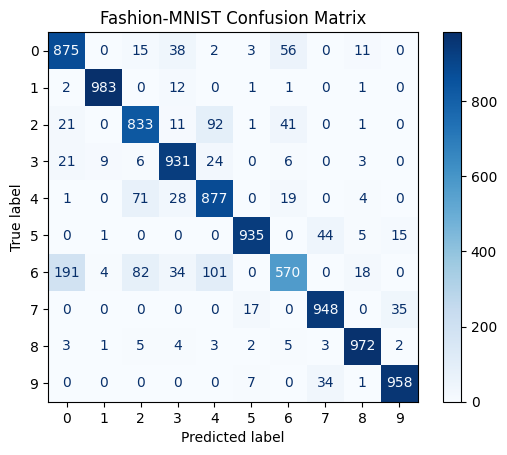

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    test_labels,
    test_predictions,
    cmap="Blues"
)

plt.title("Fashion-MNIST Confusion Matrix")
plt.show()

In [38]:
from google.colab import files

files.download("best_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>